In [8]:
import pandas as pd
import os
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor
from sklearn.model_selection import cross_val_score
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.preprocessing import StandardScaler
from sklearn.neural_network import MLPClassifier, MLPRegressor
from sklearn.decomposition import PCA
from sklearn.neighbors import KNeighborsClassifier, KNeighborsRegressor
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.base import BaseEstimator
from sklearn.linear_model import RidgeClassifier
from sklearn import svm

# from tqdm.notebook import tqdm

### Набор данных с кристаллизацией

In [9]:
crys_df = pd.read_excel("lysozyme.xlsx")
crys_df = crys_df[["precipitater", "crystallization", "R", "dimer", "octamer"]]
crys_df.index = crys_df["precipitater"]
crys_df.drop("precipitater", axis=1, inplace=True)
crys_df.head()

FileNotFoundError: [Errno 2] No such file or directory: 'lysozyme.xlsx'

### Спектры

In [28]:
# создаем словарь, где ключ - это id объекта, а значение - таблица с углами и интенсивностями
spectr_dir_root = "lysozyme_saxs/"
spectr_rows = 2578
skiprows = 3

spectr_df = {}
for file in os.listdir(spectr_dir_root):
    spec = pd.read_csv(os.path.join(spectr_dir_root, file), skiprows=skiprows, 
                       names=["scattering_angle", "intensity", "err"], 
                       nrows=spectr_rows, sep=" ", skipinitialspace=True)
    name_splitted = file.split("_")
    spectr_df[name_splitted[1][-1] + "_" + name_splitted[2]] = spec.drop("err", axis=1)

In [29]:
# Проверка на одинаковость углов (чтобы потом склеить все интенсивности)
template = np.array(spectr_df["1_1"]["scattering_angle"])
for obj_idx in spectr_df.keys():
    if np.any(template != np.array(spectr_df[obj_idx]["scattering_angle"])):
        print(obj_idx)

1_16
2_19
1_23
1_61
1_13


In [30]:
spectr_df["1_61"] # на одну запись меньше (другие также надо проверить)

,scattering_angle,intensity
0,1.496580e-01,1.666831e-02
1,1.524400e-01,1.643593e-02
2,1.552220e-01,1.652003e-02
3,1.580030e-01,1.690230e-02
4,1.607850e-01,1.644929e-02
...,...,...
2573,7.307080e+00,5.971450e-05
2574,7.309860e+00,-4.783830e-04
2575,7.312650e+00,6.471455e-04
2576,7.315430e+00,6.625720e-04


In [31]:
spectr_df["1_1"] # не хватает именно последнего значения для угла 7.318210. Удалим во всех таблицах

,scattering_angle,intensity
0,0.149658,0.016250
1,0.152440,0.015911
2,0.155222,0.015469
3,0.158003,0.016117
4,0.160785,0.015550
...,...,...
2573,7.307080,0.000300
2574,7.309860,-0.000509
2575,7.312650,0.000669
2576,7.315430,0.000504


In [32]:
# удаляем последнюю строку и переводим во float из object
for obj_idx in spectr_df.keys():
    spectr_df[obj_idx] = spectr_df[obj_idx].iloc[:-1].astype(float)

In [33]:
# Проверка на одинаковость углов
template = np.array(spectr_df["1_1"]["scattering_angle"])
for obj_idx in spectr_df.keys():
    if np.any(template != np.array(spectr_df[obj_idx]["scattering_angle"])):
        print(obj_idx)

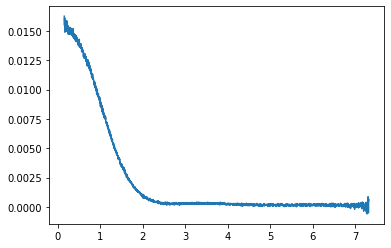

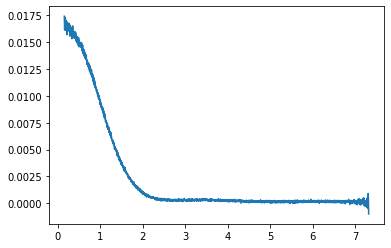

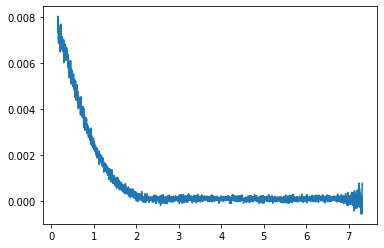

In [34]:
# построим графики для проверки. Похоже на спектр.
for i in ["1_1", "1_13", "2_19"]:
#     spectr_df[i]["intensity"].plot.bar(xticks=[])
    plt.plot(spectr_df[i]["scattering_angle"], spectr_df[i]["intensity"])
    plt.show()

In [35]:
intensity_lst = []
id_lst = []

for obj_idx in spectr_df.keys():
    spectr_df[obj_idx].drop("scattering_angle", axis=1, inplace=True) # удаляем угол
    intensity_lst.append(spectr_df[obj_idx].T) # запихиваем все интенсивности в один список
    id_lst.append(obj_idx)

In [36]:
# склеиваем все интенсивности для каждого объекта в одну таблицу. Индексом ставим id кристалла
intensity_df = pd.concat(intensity_lst)
intensity_df.index = id_lst
intensity_df.head()

,0,1,2,3,4,5,6,7,8,9,...,2567,2568,2569,2570,2571,2572,2573,2574,2575,2576
1_45,0.008356,0.008539,0.008005,0.008694,0.008471,0.008277,0.008192,0.008667,0.007761,0.007645,...,-0.000529,0.000098,0.000506,0.000431,-0.000305,0.001703,-0.000042,0.000697,-0.000283,0.000395
1_56,0.020395,0.020226,0.020034,0.020546,0.020653,0.020722,0.019915,0.020566,0.020270,0.019583,...,0.000371,0.000116,-0.000312,-0.000032,0.000464,0.000048,0.000577,-0.000456,-0.001047,0.000375
1_14,0.012603,0.012585,0.012807,0.012688,0.012501,0.012358,0.012127,0.012399,0.012862,0.012107,...,-0.000454,0.000445,-0.000407,0.000350,-0.000147,-0.000461,-0.000753,0.000183,-0.000301,-0.000997
1_35,0.018696,0.019032,0.018839,0.018028,0.019310,0.018710,0.018600,0.018136,0.018531,0.018487,...,0.000056,0.000001,-0.000043,-0.000114,-0.001116,-0.000562,0.000371,0.000187,-0.000553,0.000524
1_41,0.018303,0.018804,0.017467,0.017555,0.017467,0.017716,0.017602,0.017999,0.018229,0.017655,...,0.000727,0.000210,0.000158,0.000370,-0.000119,-0.000028,-0.000445,0.000142,-0.000471,-0.000314


In [37]:
df = intensity_df.join(crys_df) # собрали датасет воедино

In [38]:
df

,0,1,2,3,4,5,6,7,8,9,...,2571,2572,2573,2574,2575,2576,crystallization,R,dimer,octamer
1_45,0.008356,0.008539,0.008005,0.008694,0.008471,0.008277,0.008192,0.008667,0.007761,0.007645,...,-0.000305,0.001703,-0.000042,0.000697,-0.000283,0.000395,денатурация,26.8,20.5,16.0
1_56,0.020395,0.020226,0.020034,0.020546,0.020653,0.020722,0.019915,0.020566,0.020270,0.019583,...,0.000464,0.000048,0.000577,-0.000456,-0.001047,0.000375,нет,17.5,20.8,0.6
1_14,0.012603,0.012585,0.012807,0.012688,0.012501,0.012358,0.012127,0.012399,0.012862,0.012107,...,-0.000147,-0.000461,-0.000753,0.000183,-0.000301,-0.000997,нет,14.3,0.0,0.0
1_35,0.018696,0.019032,0.018839,0.018028,0.019310,0.018710,0.018600,0.018136,0.018531,0.018487,...,-0.001116,-0.000562,0.000371,0.000187,-0.000553,0.000524,нет,17.1,14.2,0.6
1_41,0.018303,0.018804,0.017467,0.017555,0.017467,0.017716,0.017602,0.017999,0.018229,0.017655,...,-0.000119,-0.000028,-0.000445,0.000142,-0.000471,-0.000314,агрегация,22.8,21.3,6.2
1_48,0.039216,0.037676,0.035405,0.033645,0.032682,0.030460,0.027860,0.026526,0.025539,0.024927,...,-0.000285,0.000971,-0.000026,0.000063,-0.000459,-0.000648,денатурация,28.2,0.0,21.1
1_17,0.014560,0.014204,0.013854,0.013830,0.014655,0.013905,0.014425,0.013696,0.013796,0.013681,...,-0.000961,-0.000372,0.000062,0.000867,-0.002361,-0.001055,нет,16.3,18.4,0.0
1_34,0.010713,0.011150,0.011208,0.010745,0.011377,0.011242,0.010604,0.011201,0.010523,0.010591,...,-0.000144,0.000586,-0.000854,-0.000419,0.000127,-0.000195,денатурация,23.5,25.1,7.4
1_60,0.011341,0.011519,0.011077,0.011562,0.011610,0.011913,0.011977,0.011107,0.011440,0.011661,...,0.000403,0.000217,0.000252,-0.000316,0.000775,0.000249,нет,21.4,23.0,4.2
1_59,0.013227,0.012516,0.012553,0.012736,0.012763,0.012839,0.012338,0.012542,0.012432,0.012814,...,-0.000422,0.000413,0.000667,0.000424,-0.000926,0.000173,агрегация,19.6,27.7,2.1


In [39]:
df.shape

(56, 2581)

**Комментарий**: в секции считывания данных все отлично. Ошибок не обнаружено

### Обучение (Классификация)

In [40]:
from sklearn.model_selection import LeaveOneOut

In [41]:
# кодируем отклик
le = LabelEncoder()
le.fit(df["crystallization"])
df["crystallization"] = le.transform(df["crystallization"])

**Комментарий**: Лучше использовать OneHotEncoder, так как он лучше совместим с *MLP* и линейными методами

In [42]:
# разделяем отклик и признаки
X = df.drop(["crystallization", "dimer", "octamer", "R"], axis=1)
y = df["crystallization"]

In [43]:
# Кросс-валидационный accuracy для случайного леса
clf = RandomForestClassifier(random_state=123)
cvs = cross_val_score(clf, X, y, cv=LeaveOneOut(), scoring="accuracy")
print("accuracy:", cvs.mean())

accuracy: 0.625


In [44]:
# # кросс-валидация на нейросети
# clf = MLPClassifier((500, 500, 10), max_iter=1000, random_state=123)
# cvs = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
# print("accuracy:", cvs.mean())

In [45]:
# скалирование (чтобы всё было +- в одном диапазоне)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

**Комментарий:** Лучше все делать по порядку - сначала отнормировать, потом обучать модели машинного обучения. Также стоит провести обучение всех моделей как с нормировкой, так и без нее, и посмотреть - сказывается ли нормировка на качестве предсказания.

In [46]:
# # кросс-валидация на нейросети со скалированными признаками
# clf = MLPClassifier((500, 500, 10), max_iter=1000, random_state=123)
# cvs = cross_val_score(clf, X_scaled, y, cv=5, scoring="accuracy")
# print("accuracy:", cvs.mean())

In [49]:
# # Кросс-валидация на нейросети с данными из PCA
# clf = MLPClassifier((5, 100, 60), max_iter=1000, random_state=123)
# cvs = cross_val_score(clf, X_pca, y, cv=5, scoring="accuracy")
# print("accuracy:", cvs.mean())

In [47]:
# Метод снижения размерности
pca = PCA(n_components=50)
pca.fit(X_scaled)
pca.explained_variance_ratio_

array([7.70880544e-01, 1.83830413e-01, 1.03799226e-02, 9.33711004e-03,
       2.09390520e-03, 1.25567957e-03, 1.13137075e-03, 9.24118146e-04,
       8.61635995e-04, 8.39567527e-04, 7.96347594e-04, 7.69295040e-04,
       7.09892779e-04, 6.80615121e-04, 6.67870556e-04, 6.22933501e-04,
       6.13012734e-04, 5.81938756e-04, 5.62624286e-04, 5.52819439e-04,
       5.16048751e-04, 4.99438190e-04, 4.89498248e-04, 4.81529911e-04,
       4.74785459e-04, 4.54998591e-04, 4.42134513e-04, 4.31952680e-04,
       4.17316657e-04, 4.04107318e-04, 3.98003412e-04, 3.85930772e-04,
       3.75216946e-04, 3.52903869e-04, 3.42641983e-04, 3.42219898e-04,
       3.29647137e-04, 3.20641754e-04, 3.15997882e-04, 3.05273391e-04,
       2.99691014e-04, 2.94051537e-04, 2.87633988e-04, 2.78656403e-04,
       2.70643831e-04, 2.65819984e-04, 2.60895834e-04, 2.54683354e-04,
       2.44632725e-04, 2.43462150e-04])

In [48]:
# Применение PCA
pca = PCA(n_components=3, random_state=123)
X_pca = pca.fit_transform(X_scaled)

**Комментарий:** Лучше не пытатьтся подобрать гиперпараметры моделей, особенно в случае *MLP*. Достаточно попробовать различные модели с дефолтными параметрами.

Модели которые нужно попробовать:
* ExtraTrees
* SVC
* Logistic
* MLP

In [24]:
from sklearn.ensemble import ExtraTreesClassifier

In [30]:
clf = ExtraTreesClassifier(random_state=123)
cvs = cross_val_score(clf, X_pca, y, cv=5, scoring="accuracy")
print("accuracy:", cvs.mean())

accuracy: 0.6242424242424243


In [31]:
# посмотрим корреляции признаков с откликом
corrs = []
for col in X.columns:
    corrs.append((abs(np.corrcoef(X[col], y)[1][0]), col))

**Комментарий**: в этом блоке использование коээфициента корреляции на самом деле ошибочно, так как с помощью коэффициента корреляции можно отслеживать лишь линейные зависимости между **числовыми** признаками. Здесь же целевой признак является номинальным, отсюда следует что коэффициент корреляции здесь применяться не должен. Вместо коэффициента корреляции для оценки важности точек следует воспользоваться функцией *f_classif* из *sklearn* или встроенной важностью признаков ансамблевых методов таких как *Random Forest*, *ExtraTrees*. 

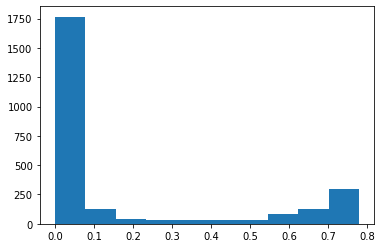

In [32]:
plt.hist(np.array(corrs)[:, 0])
plt.show()

In [33]:
# Берем только фичи, коррелирующие с откликом с корреляцией > 0.2
good_features = []
for corr, col in corrs:
    if corr > 0.2:
        good_features.append(col)

In [34]:
X_correlate = X[good_features] # можно брать фичи из X_scaled уже

In [35]:
# Кросс-валидация на нейросети с коррелирующими данными
clf = MLPClassifier((100, 10), max_iter=2000, random_state=123)
cvs = cross_val_score(clf, X_correlate, y, cv=5, scoring="accuracy")
print("accuracy:", cvs.mean())

/home/mikl/.local/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/mikl/.local/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/mikl/.local/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(
/home/mikl/.local/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


accuracy: 0.7530303030303032


/home/mikl/.local/lib/python3.9/site-packages/sklearn/neural_network/_multilayer_perceptron.py:692: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (2000) reached and the optimization hasn't converged yet.
  warnings.warn(


In [ ]:
# # пример подбора гиперпараметров на кросс-валидации
# import warnings
# warnings.filterwarnings("ignore")

# history = []
# # НУЖНО ПОДОБРАТЬ ДРУГИЕ ГИПЕРМАРАМЕТРЫ И СДЕЛАТЬ АДЕКВАТНЫЕ ДИАПОЗОНЫ
# for i in tqdm(range(5, 100, 10)): # лучше до 100
#     for j in range(5, 200, 10): # можно оставить
#         for k in range(5, 100, 10): # лучше до 100
#             reg = MLPClassifier((i, j, k), random_state=123, max_iter=1000)
#             cvs = cross_val_score(reg, X_pca, y, cv=5, scoring="accuracy")
#             mean_cvs = np.mean(cvs)
#             history.append((np.abs(mean_cvs), i, j, k))

  0%|          | 0/20 [00:00<?, ?it/s]

In [ ]:
# # топ 20 результатов подбора
# sorted(history, reverse=True)[:20]

In [37]:
# другие модели
clf = RandomForestClassifier(
    n_estimators=200,
    max_depth=1,
    min_samples_split=2,
    criterion="entropy",
    random_state=123
)
cvs = cross_val_score(clf, X_pca, y, cv=LeaveOneOut(), scoring="accuracy")
print("accuracy:", cvs.mean())

accuracy: 0.6785714285714286


In [39]:
# # другие модели
# clf = DecisionTreeClassifier(
#     max_depth=3,
#     min_samples_split=6,
#     criterion="entropy",
#     random_state=123
# )
# cvs = cross_val_score(clf, X_pca, y, cv=LeaveOneOut(), scoring="accuracy")
# print("accuracy:", cvs.mean())

In [41]:
# другие модели
clf = KNeighborsClassifier(
    n_neighbors=6
)
cvs = cross_val_score(clf, X_pca, y, cv=LeaveOneOut(), scoring="accuracy")
print("accuracy:", cvs.mean())

accuracy: 0.6785714285714286


In [42]:
clf = LogisticRegression(C=3, multi_class="ovr")
cvs = cross_val_score(clf, X_pca, y, cv=5, scoring="accuracy")
print("accuracy:", cvs.mean())

accuracy: 0.7515151515151516


In [88]:
clf = svm.SVC(C=1, kernel="rbf")
cvs = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
print("accuracy:", cvs.mean())

accuracy: 0.6636363636363637


In [37]:
clf = RidgeClassifier(alpha=3)
cvs = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
print("accuracy:", cvs.mean())

accuracy: 0.4636363636363637


**Комментарий:**  
  
Задание 1:  
Визуализировать предсказание лучшей модели с помощью confusion matrix (есть в sklearn)  
  
Задание 2:  
2.1 Отобрать (любым подходящим методом) два лучших признака  
2.2 Обучить на них одну линейную и одну нелинейную модели  
2.3 Постороить тепловые карты предсказания, используя обученные модели (код есть в одном из ноутбуков). Нанести на нее точки исходной выборки, истинный класс каждой точки обозначить цветом.  

In [ ]:
# 1.1
# from sklearn.metrics import confusion_matrix

# y_true = ... # тут вектор разметки
# y_pred = ... # тут вектор предсказания
# cm = confusion_matrix(y_true, y_pred,normalize='true')
# sns.heatmap(cm)

In [ ]:
# 2.1
# PCA

# 2.2
# Линейная - логистическая или линейная регрессии
# Нелинейна - MLPClassifier, MLPRegresor.

# Обучение (регрессия)

**Комментарий:**

Модели которые нужно попробовать:
* ExtraTrees
* SVR
* Ridge
* MLP

Помимо RMSE для оценки качества также использовать R<sup>2</sup>-score

In [41]:
# предсказываю R
y = df["R"]

In [42]:
clf = RandomForestRegressor(
    n_estimators=200,
    max_depth=2,
    random_state=123
)
cvs = cross_val_score(clf, X, y, cv=5, scoring="neg_root_mean_squared_error")
print("RMSE:", abs(cvs).mean())

RMSE: 2.178480554427537


In [43]:
clf = RandomForestRegressor(
    n_estimators=200,
    max_depth=2,
    random_state=123
)
cvs = cross_val_score(clf, X_correlate, y, cv=5, scoring="neg_root_mean_squared_error")
print("RMSE:", abs(cvs).mean())

RMSE: 2.0954385516963674


In [44]:
clf = LinearRegression()
cvs = cross_val_score(clf, X_scaled, y, cv=5, scoring="neg_root_mean_squared_error")
print("RMSE:", abs(cvs).mean())

RMSE: 1.4748199837849052


In [45]:
clf = KNeighborsRegressor(n_neighbors=6)
cvs = cross_val_score(clf, X_pca, y, cv=5, scoring="neg_root_mean_squared_error")
print("RMSE:", abs(cvs).mean())

RMSE: 1.9142671586863926


In [46]:
clf = MLPRegressor((30, 40, 10), max_iter=3000, random_state=123)
cvs = cross_val_score(clf, X_correlate, y, cv=5, scoring="neg_root_mean_squared_error")
print("RMSE:", abs(cvs).mean())

C:\Users\ПОЛЬЗОВАТЕЛЬ\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:690: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (3000) reached and the optimization hasn't converged yet.
  warnings.warn(


RMSE: 5.407354111732665


**Комментарий:**  
  
Задание 1:  
Визуализировать предсказание лучшей модели с помощью true-preddicted scatterplot (используя, например, библиотеку seaborn)  
  
Задание 2:  
2.1 Отобрать (любым подходящим методом) два лучших признака  
2.2 Обучить на них одну линейную и одну нелинейную модели  
2.3 Постороить тепловые карты предсказания, используя обученные модели (код есть в одном из ноутбуков). Нанести на нее точки исходной выборки, истинное значение таргета в каждой точке обозначить цветом.  

In [ ]:
# 1.1
# import seaborn as sns

# sns.scatterplot(data=t, x=y_true, y=y_pred)
# t - таблица из которой берешь данные
# y_true - реальные метки
# y_pred - предсказания

## заметки

Новые признаки, которые стоит попробовать:
1) Максимальное/минимальное/среднее/дисперсия/различные квантили значение интенсивности; \
2) Угол рассеивания с максимальной/минимальной интенсивностью; \
3) и т. д.

**Комментарий:** Идея ввести новые признаки кажется очень даже разумной. Ее стоит обсудить всем вместе на следующей итерации.

In [47]:
# создаем словарь, где ключ - это id объекта, а значение - таблица с углами и интенсивностями
spectr_dir_root = "lysozyme_saxs/"
spectr_rows = 2578
skiprows = 3

spectr_df = {}
for file in os.listdir(spectr_dir_root):
    spec = pd.read_csv(os.path.join(spectr_dir_root, file), skiprows=skiprows, 
                       names=["scattering_angle", "intensity", "err"], 
                       nrows=spectr_rows, sep=" ", skipinitialspace=True)
    name_splitted = file.split("_")
    spectr_df[name_splitted[1][-1] + "_" + name_splitted[2]] = spec.drop("err", axis=1)
    
# удаляем последнюю строку и переводим во float из object
for obj_idx in spectr_df.keys():
    spectr_df[obj_idx] = spectr_df[obj_idx].iloc[:-1].astype(float)

In [48]:
features = []
idxs = []
for obj_idx in spectr_df.keys():
    obj_feature = []
    idxs.append(obj_idx)
    obj_feature.append(spectr_df[obj_idx]["intensity"].max())
    obj_feature.append(spectr_df[obj_idx]["intensity"].min())
    obj_feature.append(spectr_df[obj_idx]["intensity"].mean())
    obj_feature.append(spectr_df[obj_idx]["intensity"].var())
    for q in np.linspace(0.1, 0.9, 9):
        obj_feature.append(spectr_df[obj_idx]["intensity"].quantile(q))
    features.append(obj_feature)

In [49]:
feature_eng = pd.DataFrame(features, index=idxs)

In [50]:
df_eng = feature_eng.join(crys_df)

In [51]:
le = LabelEncoder()
le.fit(df_eng["crystallization"])
df_eng["crystallization"] = le.transform(df_eng["crystallization"])

# разделяем отклик и признаки
X = df_eng.drop(["crystallization", "dimer", "octamer", "R"], axis=1)
y = df_eng["crystallization"]

# кросс-валидация на RF
clf = RandomForestClassifier(random_state=123)
cvs = cross_val_score(clf, X, y, cv=5, scoring="accuracy")
print("accuracy:", cvs.mean())



#НАДО ПОКРУТИТЬ, ПОПРОБОВАТЬ КАК-ТО 


accuracy: 0.5878787878787879
